In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [5]:
data=pd.read_csv("Cleaned_apps_data.csv")
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


##Our main objective in this analysis:

Explore this dataset
Here are some ideas to get your started with your analysis...

🗺️ Explore: Which categories get the highest reviews from amongst the 10 most popular categories?

📊 Visualize: Create a plot visualizing the distribution of sentiment polarity, split by content rating.

🔎 Analyze: What impact does the content rating an app receives have on its sentiment and rating?

In [9]:
data["Rating"].dtypes

dtype('float64')

In [11]:
data["Reviews"].dtypes

dtype('int64')

In [13]:
data["Installs"].dtypes

dtype('O')

In [23]:
#To explore the 10 most popular categories we need to sum the total installs
#Installs columns must be in integer type
data["Installs"]=(data["Installs"].str.replace("+", "", regex=False).str.replace(",", "", regex=False).astype(int))

In [25]:
data["Installs"].dtypes

dtype('int32')

In [27]:
data["Installs"].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int32

In [85]:
#Now we can group the TOP 10 categories by installs volume
Categories_installs=(data.groupby("Category")["Installs"].sum().reset_index())
Categories_installs.head(10)

,Category,Installs
0,ART_AND_DESIGN,124333100
1,AUTO_AND_VEHICLES,53130211
2,BEAUTY,27197050
3,BOOKS_AND_REFERENCE,1921468576
4,BUSINESS,1001914865
5,COMICS,56086150
6,COMMUNICATION,32647276251
7,DATING,264310807
8,EDUCATION,871452000
9,ENTERTAINMENT,2869160000


In [87]:
TOP_10_Categories=Categories_installs.sort_values(by="Installs",ascending=False).head(10).reset_index().drop(["index"],axis=1)

In [89]:
TOP_10_Categories

,Category,Installs
0,GAME,35086024415
1,COMMUNICATION,32647276251
2,PRODUCTIVITY,14176091369
3,SOCIAL,14069867902
4,TOOLS,11452271905
5,FAMILY,10258203405
6,PHOTOGRAPHY,10088247655
7,NEWS_AND_MAGAZINES,7496317760
8,TRAVEL_AND_LOCAL,6868887146
9,VIDEO_PLAYERS,6222002720


This dataframe shows the most popular apps categories having highest installs volume

In [99]:
#Checking TOP_10 Categories data
filtered_data=data[data["Category"].isin(TOP_10_Categories["Category"])]

# Aggregate reviews
category_reviews = (filtered_data.groupby("Category")["Reviews"].sum().reset_index())

# Sort by reviews
category_reviews_sorted = category_reviews.sort_values(by="Reviews", ascending=False).reset_index().drop(["index"],axis=1)

category_reviews_sorted

,Category,Reviews
0,GAME,1585422349
1,COMMUNICATION,815462260
2,SOCIAL,621241422
3,FAMILY,410226107
4,TOOLS,273181033
5,PHOTOGRAPHY,213516650
6,PRODUCTIVITY,114116975
7,VIDEO_PLAYERS,110380188
8,TRAVEL_AND_LOCAL,62617919
9,NEWS_AND_MAGAZINES,54400863


This dataframe shows the TOP 10 Categories having the heighest number of engagement (reviews)

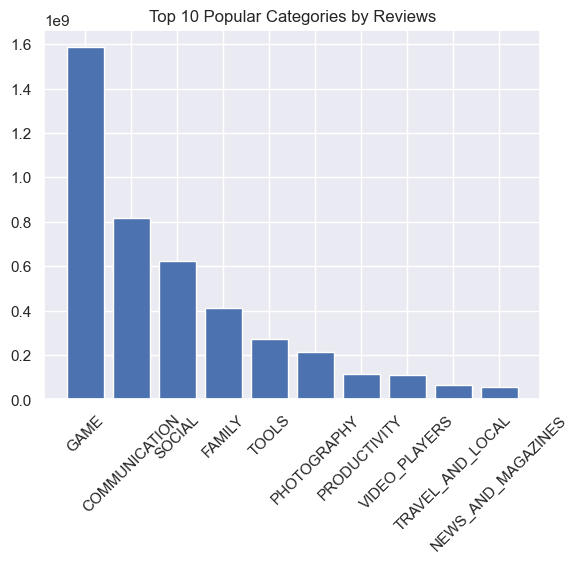

In [102]:
plt.figure()
plt.bar(category_reviews_sorted["Category"],
        category_reviews_sorted["Reviews"])
plt.xticks(rotation=45)
plt.title("Top 10 Popular Categories by Reviews")
plt.show()

In [109]:
#saving dataframes
TOP_10_Categories.to_csv("TOP10_Categories_by_Installs.csv")
category_reviews_sorted.to_csv("TOP10_Categories_by_Reviews.csv")

In [113]:
reviews_data=pd.read_csv("googleplaystore_user_reviews.csv")
reviews_data.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [117]:
reviews_data.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [125]:
reviews_data=reviews_data.dropna().reset_index()

In [127]:
reviews_data.isnull().sum()

index                     0
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [129]:
reviews_data.head()

,index,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,5,10 Best Foods for You,Best way,Positive,1.00,0.300000
